# Pivot in pandas

## Import libraries

In [57]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## what is pivot?
In Pandas, ```.pivot()``` function is used to reshape your DataFrame by turning unique values from one column into new columns, while reorganizing the data around an index. <br>
syntax : ```DataFrame.pivot(index=None, columns=None, values=None)``` <br>
**Parameters** : <br>
- index : column(s) to use as row labels
- columns : column whose unique values will become new columns
- values : column whose values will fill new table (cells)'
## Let's look at an example:

In [58]:
#generate a sample data for pivot demonstration
data = {
    "city": ["mumbai", "mumbai", "delhi", "delhi", "lucknow", "lucknow"],
    "date": ["2025-08-01", "2025-08-02", "2025-08-01", "2025-08-02", "2025-08-01", "2025-08-02"],
    "temperature": [30, 32, 40, 42, 35, 37]
}

In [59]:
df_pivot = pd.DataFrame(data)
df_pivot

,city,date,temperature
0,mumbai,2025-08-01,30
1,mumbai,2025-08-02,32
2,delhi,2025-08-01,40
3,delhi,2025-08-02,42
4,lucknow,2025-08-01,35
5,lucknow,2025-08-02,37


In [60]:
pivoted_df = df_pivot.pivot(index="date",columns="city",values="temperature")
pivoted_df

city,delhi,lucknow,mumbai
date,,,
2025-08-01,40,35,30
2025-08-02,42,37,32


### Explaination:
- ```date``` became the index (rows)
- ```city``` values (```mumbai```, ```delhi```, ```lucknow```) became new columns.
- ```temperature``` values filled the table.
<br>
So instead of having a long format data (row-wise) now we have a wide format table where each city's temperature is in its own column.

### Limitations of ```pivot```
1. It doen't allow duplicates for the combination of ```index``` + ```columns```
   - If you have duplicates, Pandas will throw an error.
   - Exmple : If ```mumbai``` city has two temperature recorded on the same date then ```pivot``` won't know which one to use.
   - In that case, you should use ```pivot_table()``` instead, because it allows aggregation (mean,sum,etc...)
2. Works best with clean and tidy data where one combination of index and column is unique.



## Senarios where reshaping dataFrame using ```.pivot()``` function might help
Pivoting (reshaping) shines whenever you need to turn "long and tidy" rows into a "wide" table so each category gets its own column. That unlocks plotting, reporting ML feature building, and matrix - like analysis.

### 1. Time-series by category (easy plotting and comparision)
Goal: One line per city on a single chart.

In [61]:
df_ex1 = pd.DataFrame({
    "date": ["2025-01-01","2025-01-01","2025-01-02","2025-01-02"],
    "city": ["mumbai","delhi","mumbai","delhi"],
    "temp": [30, 40, 32, 42]
})

wide_ex1 = df_ex1.pivot(index="date",columns="city",values="temp")
wide_ex1

city,delhi,mumbai
date,,
2025-01-01,40,30
2025-01-02,42,32


**Why pivot helps :** Many plotting functions expect one column per series. After pivot, ```wide.plot()``` draws both city lines immidiately.

#### Example code to explain ```Why pivot helps : Many plotting functions expect one column per series. After pivot, wide.plot() draws both city lines immidiately.```

In [62]:
# generate data simulating a dataFrame having multiple city data related to temperature by date.
india_weather_temperature = {
    "date": pd.date_range(start="2025-08-01", periods=5).tolist() * 3,
    "city": ["mumbai"] * 5 + ["lucknow"] * 5 + ["delhi"] * 5,
    "Temperature": [
        # Mumbai (warm and stable)
        29, 30, 31, 28, 29,
        # Lucknow (hotter variation)
        34, 36, 33, 35, 37,
        # Delhi (very hot summers)
        38, 40, 39, 41, 42
    ],
}

# create a dataFrame out of this data
india_weather_temperature_df_ex2 = pd.DataFrame(india_weather_temperature)
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


Let's plot a graph and see how it looks

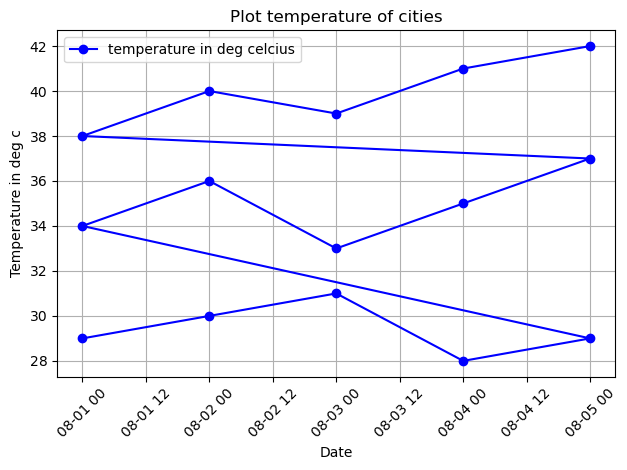

In [63]:
plt.title("Plot temperature of cities")
plt.plot(india_weather_temperature_df_ex2["date"],india_weather_temperature_df_ex2["Temperature"],linestyle="-",marker="o",color="blue",label="temperature in deg celcius")
plt.xlabel("Date")
plt.ylabel("Temperature in deg c")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

#### Solution method 1 : Use groupby to group the temperatures by cities and then plot it using pyplot in the graph manually using a forloop

In [64]:
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


In [65]:
# group the temperature based on cities 
india_weather_temperature_df_ex2_groupby = india_weather_temperature_df_ex2.groupby("city")
india_weather_temperature_df_ex2_groupby

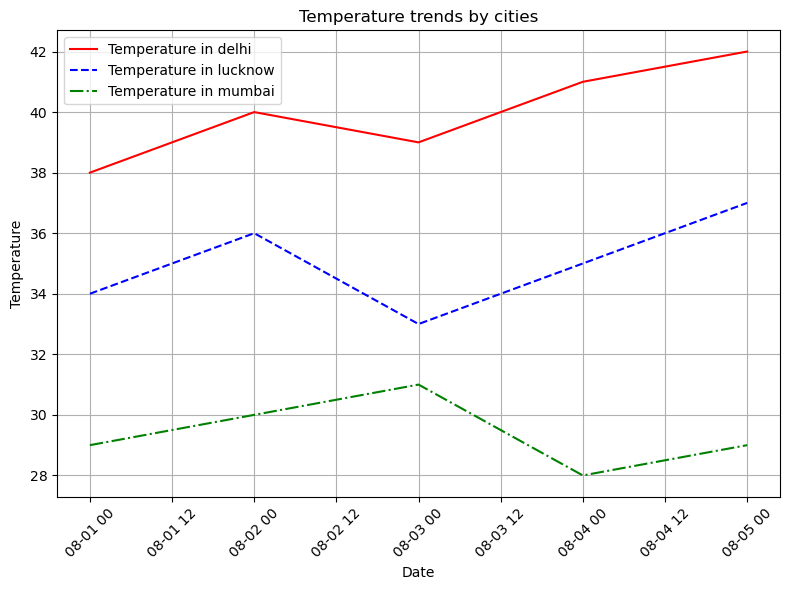

In [66]:
import itertools

linestyle_list = ["-", "--", "-."]
color_list = ["red","blue","green"]

linestyle_cycle = itertools.cycle(linestyle_list)
color_cycle = itertools.cycle(color_list)

plt.figure(figsize=(8,6))
plt.title("Temperature trends by cities")
for city, city_df in india_weather_temperature_df_ex2_groupby:
    plt.plot(city_df["date"],city_df["Temperature"],label=f"Temperature in {city}",linestyle=next(linestyle_cycle),color=next(color_cycle))
plt.grid(True)
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Temperature")
plt.tight_layout()
plt.legend()
plt.show()

#### Using barcharts 

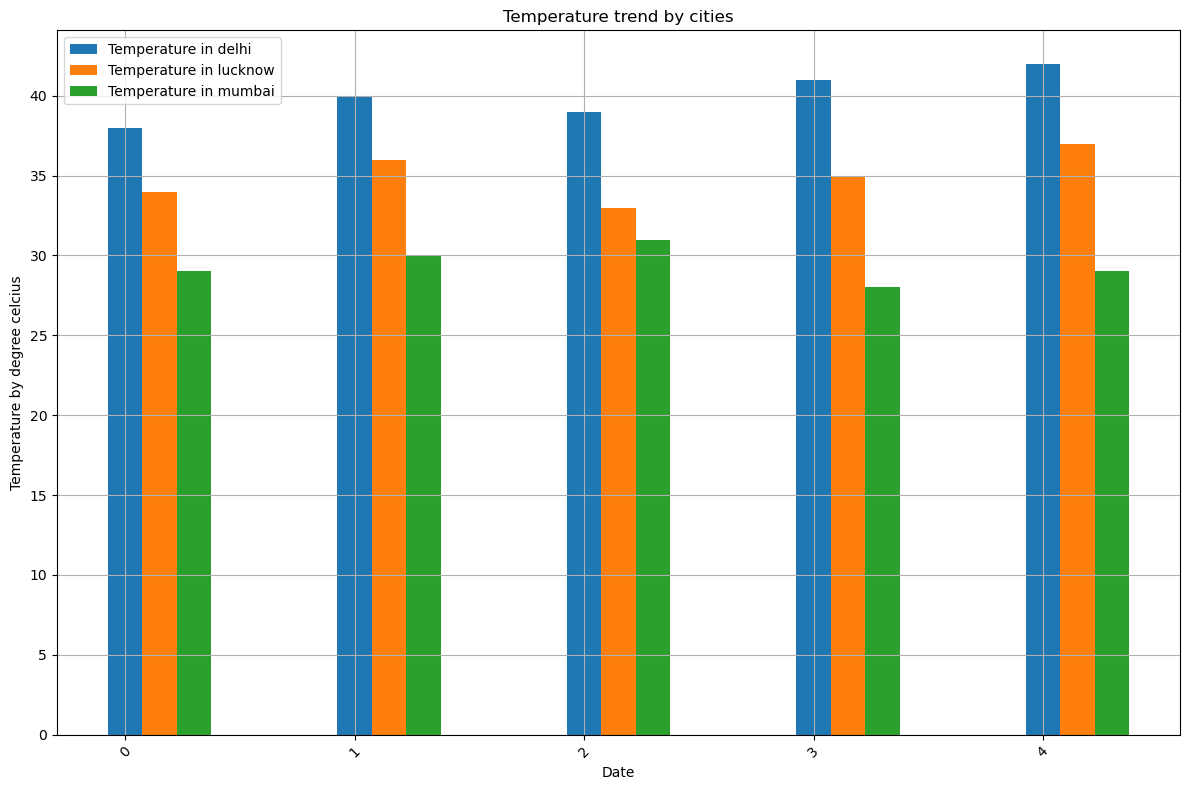

In [67]:
dates = sorted(india_weather_temperature_df_ex2["date"].unique())
x = np.arange(len(dates))
width = 0.15

plt.figure(figsize=(12,8))
for i, (city,city_df) in enumerate(india_weather_temperature_df_ex2_groupby):
    plt.bar(
        x + i * width,
        city_df["Temperature"],
        width=width,
        label=f"Temperature in {city}"
    )
plt.title("Temperature trend by cities")
plt.xlabel("Date")
plt.ylabel("Temperature by degree celcius")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

#### Solution method 2: Privot (reshape) the dataFrame in a way that each city has its own column instead of the rows.

In [68]:
india_weather_temperature_df_ex2

,date,city,Temperature
0,2025-08-01,mumbai,29
1,2025-08-02,mumbai,30
2,2025-08-03,mumbai,31
3,2025-08-04,mumbai,28
4,2025-08-05,mumbai,29
5,2025-08-01,lucknow,34
6,2025-08-02,lucknow,36
7,2025-08-03,lucknow,33
8,2025-08-04,lucknow,35
9,2025-08-05,lucknow,37


In [69]:
wide_df4 = india_weather_temperature_df_ex2.pivot(index="date",columns="city",values="Temperature")
wide_df4

city,delhi,lucknow,mumbai
date,,,
2025-08-01,38,34,29
2025-08-02,40,36,30
2025-08-03,39,33,31
2025-08-04,41,35,28
2025-08-05,42,37,29


Now each city has it's own column

Let's plot in graph after the pivot operation now

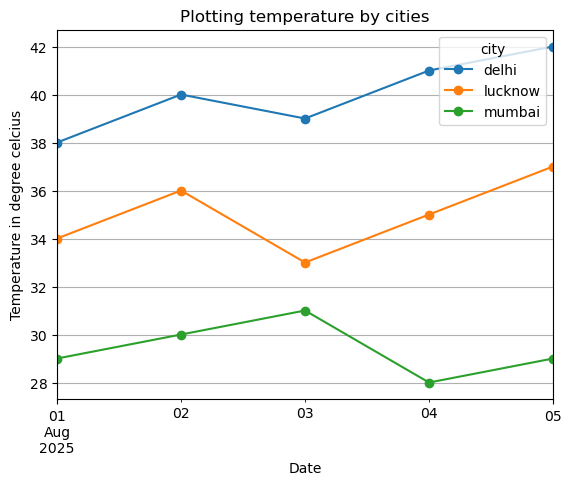

In [70]:
wide_df4.plot(marker="o",linestyle="-")
plt.title("Plotting temperature by cities")
plt.ylabel("Temperature in degree celcius")
plt.grid(True)
plt.xlabel("Date")
plt.show()

As you can see there 
- colors are automatically cycled but incase when we used the groupby method we had to cycle through colors manually using ```itertools```
- And the results are the same as what I have achieved when we applied groupby method to plot temperature trends by cities
- The line of code also got reduced

<br>

Pivoting (reshaping) dataFrames only works well when data is clean and tidy reshaping won't work if the data is not clean. 

<br>

**Why pivot helps?** <br>
Most plotting functions like (```.plot()```, ```matplotlib```, ```seaborn.heatmap```) treat each numeric columns as a separate seires.
- In long format, all temps are in one columns : You need grouping logic.
- In wide format, each city is a column : ```.plot()``` automatically knows to draw one line per column.

### 2. Metric names to columns (dashboard/ KPI tables)
Goal: Daily KPIS in columns for easy reading/export. <br>
**What is KPI tables?** <br>
A KPI is a measurable value that indicates progress toward a goal. It means a **Key Performance Indicator table**. It's basically a structured way of tracking the most important metrics (KPIs) for a business, process or project.

In [71]:
# generate data 

# function to make sure the number of rows is divisible by the number elements in the metrics_list
def rows_must_be_divisible(number_of_rows,metrics_list):
    if not number_of_rows%len(metrics_list):
        return True
    else:
        False

# function to generate data for KPI
def generate_data_for_KPI(number_of_rows, metrics_list):
    if not rows_must_be_divisible(number_of_rows,metrics_list):
        raise ValueError(f"number of rows must be divisible by {len(metrics_list)}")
    n_rows = number_of_rows
    dates = pd.date_range("2025-01-01",periods = n_rows // 3 , freq="D")
    metrics = metrics_list

    data = {
        # repeat dates each for 3 matrics
        "date" : np.repeat(dates,3)[:n_rows],
        # cicle matrics
        "metrics" : metrics * (n_rows // 3) + metrics[:n_rows % 3],
        # random values
        "value" : np.random.randint(100,2000,size=n_rows)
    }
    return data 

#### Explaination : ```dates = pd.date_range("2025-01-01", periods = n_rows // 3 , freq="D")```
- ```pd.date_range``` : generates a sequence of dates
- ```2025-01-01``` : start date.
- ```periods = n_rows // 3``` : The number of dates generated
  - Here, ```n_rows // 3``` means integer division (divide ```n_rows``` by 3 and take only the whole number part)
  - Example: If ```n_rows = 44```, then ```44 // 4 = 15``` so it egenrates 14 dates accordingly
- ```freq="D"``` : frequency = daily, so the dates are consecutive days.

#### Explaination : ```"metrics" : metrics * (n_rows // 3) + metrics[:n_rows % 3]```
- This is building the ```"metrics"```column.
  - ```metrics``` : suppose it's ```["revenue", "users", "orders"]```.
  - ```metrics * (n_rows // 3)``` : repeats the whole list ```(n_rows // 3)``` times.
    - Example: If ```n_rows = 44``` , then ```n_rows // 4 = 14```.
    - So it repeats the list 14 times : 42 entries.
  - ```metrics[:n_rows % 3]``` : takes the remainder part
    - ```n_rows % 3``` is the leftover rows after making groups of 3.
    - Example : ```44 % 3 = 2```, so it takes the first 2 metrics : ```["revenue","users"]```

In [72]:
number_of_rows = 45
metrics_list = ["revenue","users","orders"]

# create dataFrame using the generated data
df_kpi = pd.DataFrame(generate_data_for_KPI(number_of_rows,metrics_list))
df_kpi

,date,metrics,value
0,2025-01-01,revenue,1779
1,2025-01-01,users,717
2,2025-01-01,orders,1789
3,2025-01-02,revenue,224
4,2025-01-02,users,1156
5,2025-01-02,orders,1737
6,2025-01-03,revenue,917
7,2025-01-03,users,1421
8,2025-01-03,orders,1549
9,2025-01-04,revenue,1328


#### Performing pivot (reshaping) operation on dataFrame

In [73]:
kpis = df_kpi.pivot(index="date",columns="metrics",values="value")
kpis

metrics,orders,revenue,users
date,,,
2025-01-01,1789,1779,717
2025-01-02,1737,224,1156
2025-01-03,1549,917,1421
2025-01-04,1004,1328,1869
2025-01-05,1314,820,633
2025-01-06,1123,421,276
2025-01-07,459,1199,250
2025-01-08,948,1383,1832
2025-01-09,102,1586,1759


#### **Easier to plot graphs**

#### Plot the data in a graph

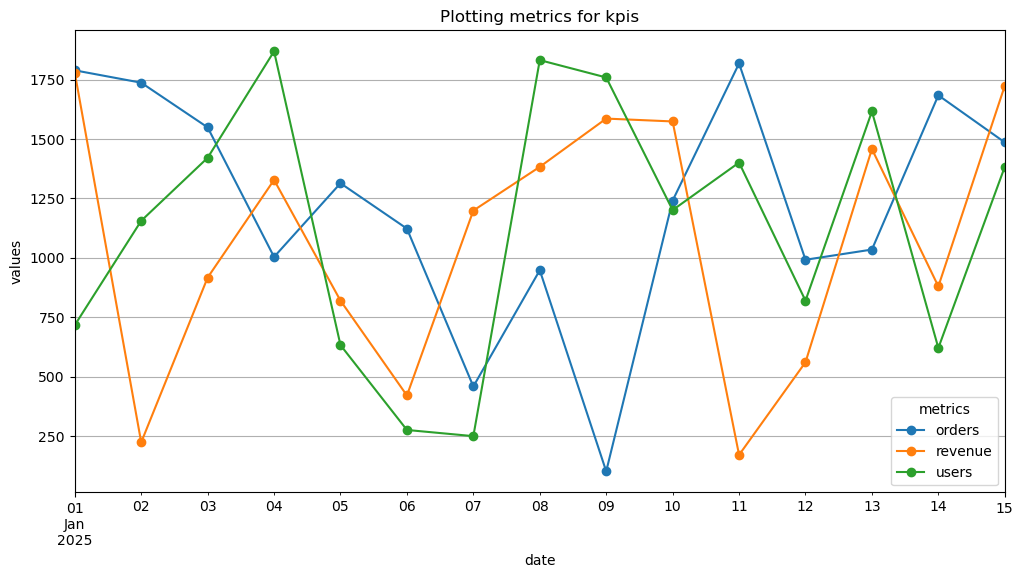

In [74]:
kpis.plot(marker="o",linestyle="-",figsize=(12,6))
plt.title("Plotting metrics for kpis")
plt.ylabel("values")
plt.xlabel("date")
plt.grid(True)
plt.show()

#### Plot bar graph instead

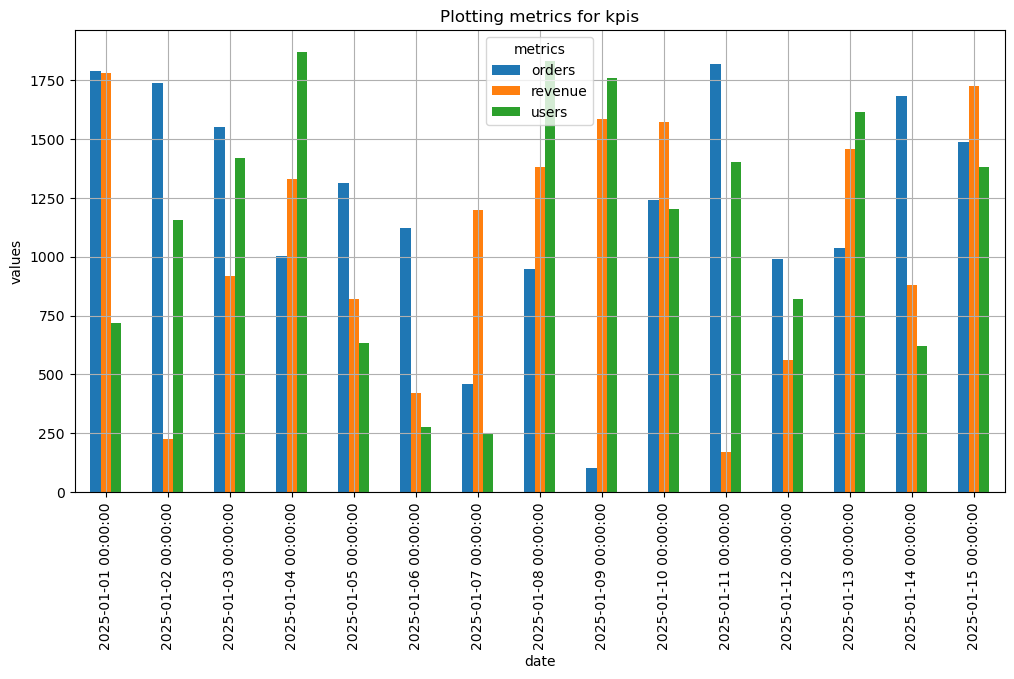

In [75]:
kpis.plot(kind="bar",figsize=(12,6))
plt.title("Plotting metrics for kpis")
plt.ylabel("values")
plt.xlabel("date")
plt.grid(True)
plt.show()

#### **Easier to calculate metrics**

In [76]:
kpis["ASP"] = kpis["revenue"]/kpis["orders"]
kpis

metrics,orders,revenue,users,ASP
date,,,,
2025-01-01,1789,1779,717,0.994410
2025-01-02,1737,224,1156,0.128958
2025-01-03,1549,917,1421,0.591995
2025-01-04,1004,1328,1869,1.322709
2025-01-05,1314,820,633,0.624049
2025-01-06,1123,421,276,0.374889
2025-01-07,459,1199,250,2.612200
2025-01-08,948,1383,1832,1.458861
2025-01-09,102,1586,1759,15.549020


Here ```ASP``` is Average Selling Price. 
- If you divide the total revenue by the number of orders recieved you will get the average selling price as a result
#### This goes to show that its easier to compute from long format dataFrame, because metrics are already in separate columns.

#### Plotting the graph to show average selling price

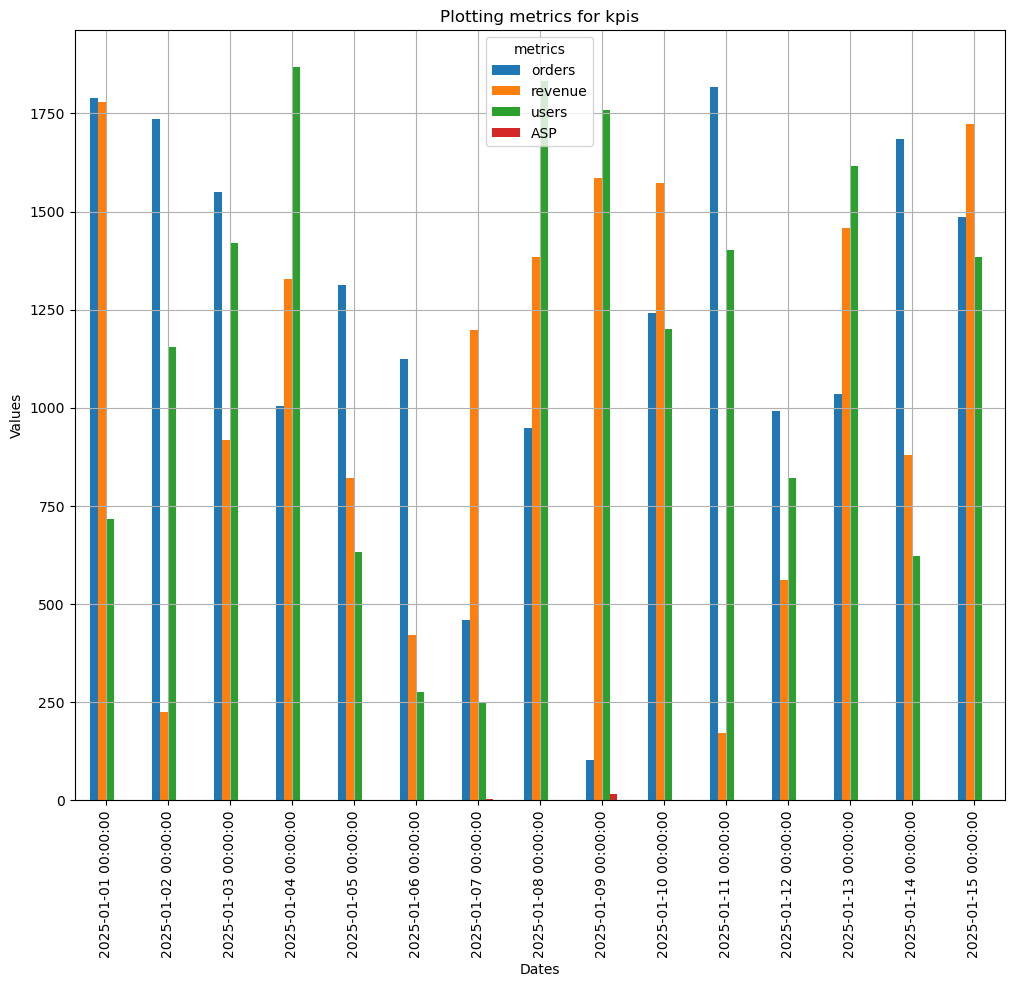

In [77]:
kpis.plot(kind="bar",figsize=(12,10))
plt.title("Plotting metrics for kpis")
plt.ylabel("Values")
plt.xlabel("Dates")
plt.grid(True)
plt.show()

#### So the ASP data bar doesn't show up even though it shows up in the graph's legend
The reason why ASP doesn’t show up in your bar chart even though it appears in the legend is because of scale mismatch.
#### Solution: 
Plot the ASP data separately 

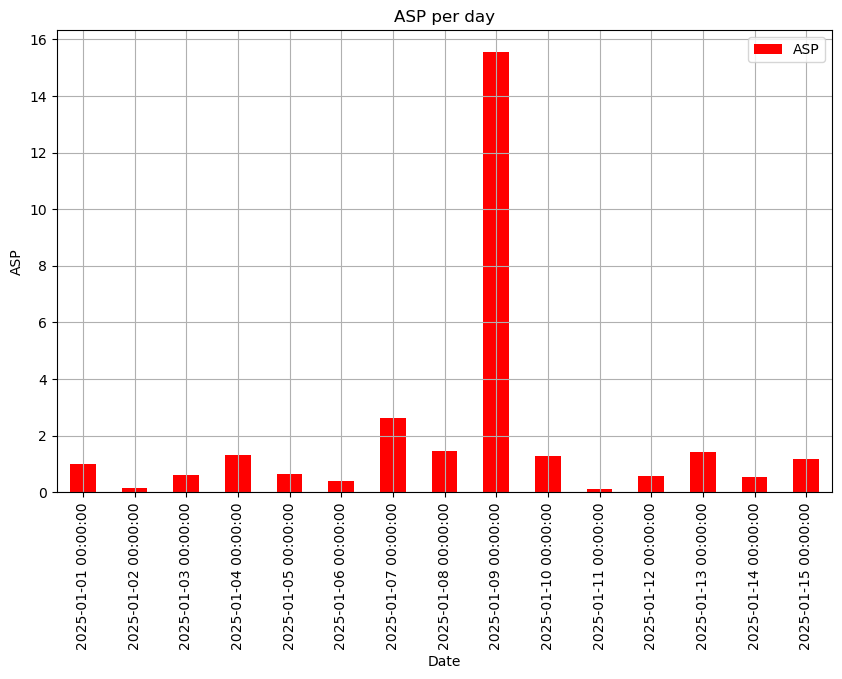

In [78]:
kpis["ASP"].plot(kind="bar",figsize=(10,6),color="red",legend=True)
plt.title("ASP per day")
plt.ylabel("ASP")
plt.xlabel("Date")
plt.grid(True)
plt.show()

Now the data in the ASP column is being shown correctly

### 3. Finance / Stock Market Data

#### import necessary libraries

In [79]:
import random 
from datetime import datetime , timedelta
from typing import List, Dict, Any
import itertools
import random

#### Generate data

In [80]:
def generate_stockmarket_data(data:List[Dict[str,Any]]=None, stocks:List[str]=None, start_date:datetime=None) -> List[Dict[str,Any]]: 
    # Validate if the input provided is in correct type or not
    if not isinstance(data,list):
        raise TypeError("Data must be of type List of Dictionaries")
    if not isinstance(stocks,list):
        raise TypeError("Stocks must be of type List")
    if not isinstance(start_date,datetime):
        raise TypeError("start_date must be of type datetime object")
    
    # Checking if data is not present if not then raise ValueError
    if not data:
        raise ValueError("Initial data required!")
    if not stocks:
        raise ValueError("Company stock names required!")
    if not start_date:
        raise ValueError("Start Date required!")
    while len(data) < 30:
        for stock in stocks:
            if len(data) >= 30:
                break
            base_price = {"AAPL": 180, "MSFT": 340, "GOOG": 140, "AMZN": 130}[stock]
            price = base_price + random.randint(-5, 10)

            # Append row
            data.append({
                "date":start_date.strftime("%Y-%m-%d"),
                "stock":stock,
                "price":price
            })
            start_date += timedelta(days=1)

    return data

#### Create dataFrame from the generated stock data

In [81]:
# initial data
data = [
    {"date": "2025-01-01", "stock": "AAPL", "price": 185},
    {"date": "2025-01-01", "stock": "MSFT", "price": 350},
    {"date": "2025-01-02", "stock": "AAPL", "price": 187},
    {"date": "2025-01-02", "stock": "MSFT", "price": 355},
]
stocks = ["AAPL", "MSFT", "GOOG", "AMZN"]
start_date = datetime(2025, 1, 3)

# create dataFrame
stock_df_original = pd.DataFrame(generate_stockmarket_data(data,stocks,start_date))
stock_df_original

,date,stock,price
0,2025-01-01,AAPL,185
1,2025-01-01,MSFT,350
2,2025-01-02,AAPL,187
3,2025-01-02,MSFT,355
4,2025-01-03,AAPL,189
5,2025-01-04,MSFT,344
6,2025-01-05,GOOG,142
7,2025-01-06,AMZN,138
8,2025-01-07,AAPL,179
9,2025-01-08,MSFT,346


#### Let's perform groupby method on it to plot the data in the same dataFrame

In [82]:
stock_df = stock_df_original.copy()
groupby_stock_obj = stock_df.groupby("stock")
groupby_stock_obj

Plot the data in the graph

Trying to plot the group using date in the x axis

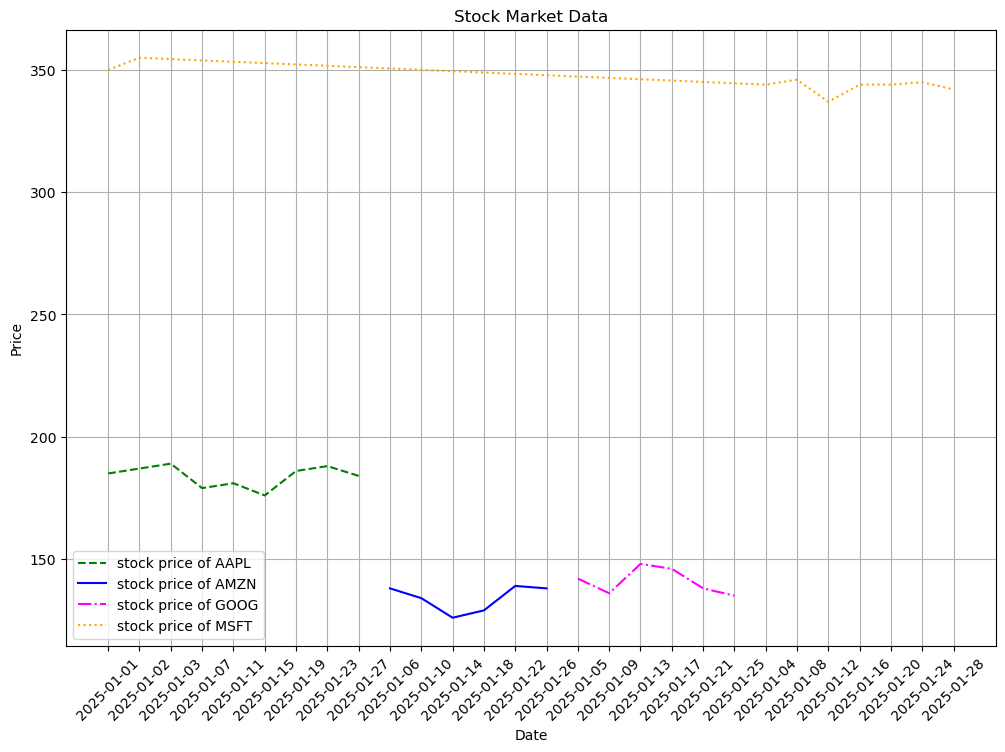

In [83]:
# create a color list
color_list = ["green","blue","magenta","orange"]
# create a linestyle_list
linestyle_list = ["--","-","-.",":"]

# create cyclic list using itertools
color_cycle = itertools.cycle(color_list)
linestyle_cycle = itertools.cycle(linestyle_list)

plt.figure(figsize=(12,8))
for stock, stock_df in groupby_stock_obj:
    plt.plot(stock_df["date"],stock_df["price"],color=next(color_cycle),linestyle=next(linestyle_cycle),label=f"stock price of {stock}")
plt.title("Stock Market Data")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

#### So what's happening here ?
```python
plt.plot(stock_df["date"], stock_df["price"], ...)
```
<br>

- Here I am plotting date(x-axis) vs price(y-axis).
- Since my DataFrame (```stock_df```) has multiple rows for each stock with different dates, matplotlib draws a continuous line for each stock across time.
- Grouping works as expected because within each group (```stock```), there's a time series (```date``` vs ```price```).
- But the key point is that this graph is not very useful

#### Let's try pivot method and reshape the dataFrame 

In [84]:
pivoted_stock_df = stock_df_original.pivot(index="date",columns="stock",values="price")
pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.0,NaN,NaN,350.0
2025-01-02,187.0,NaN,NaN,355.0
2025-01-03,189.0,NaN,NaN,NaN
2025-01-04,NaN,NaN,NaN,344.0
2025-01-05,NaN,NaN,142.0,NaN
2025-01-06,NaN,138.0,NaN,NaN
2025-01-07,179.0,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,346.0
2025-01-09,NaN,NaN,136.0,NaN


#### Now Let's plot this data and see that we get 

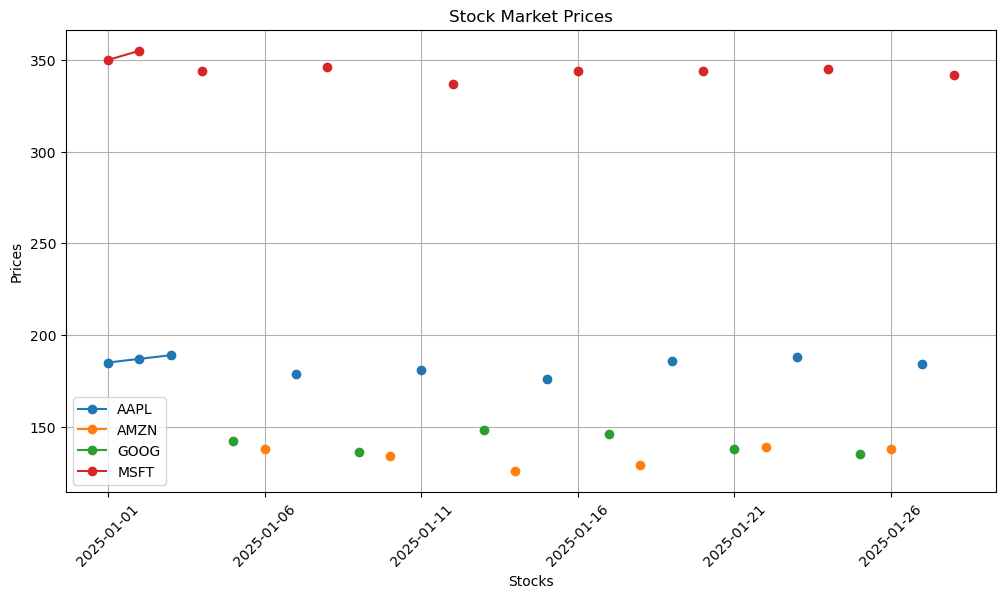

In [85]:
pivoted_stock_df.plot(marker="o",linestyle="-",figsize=(12,6))
plt.title("Stock Market Prices")
plt.xlabel("Stocks")
plt.ylabel("Prices")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

#### As you can see since the data is not clean we have to clean the data first to be able to make sense of this graph
- There is a lot of missing values that is present in the dataFrame after pivoting process is completed.
- Since we are dealing with ```NaN``` values we have to interpolate the data using time interpolation method
- Reason I am chosing time interpolation method is because we have dates as index in this dataFrame.

#### First lets verify wheather the index in this dataFrame is of type datetime or not

In [86]:
pd.api.types.is_datetime64_any_dtype(pivoted_stock_df.index)

False

In [87]:
pivoted_stock_df.index.dtype

dtype('O')

#### This means the index is not of type datetime 
Since the index of this dataFrame ```pivoted_stock_df``` is not of type datetime. We have to convert it into the type datetime.

In [88]:
pivoted_stock_df.index = pd.to_datetime(pivoted_stock_df.index)

#### Let's verify if the index is of type datetime

In [89]:
pd.api.types.is_datetime64_any_dtype(pivoted_stock_df.index)

True

In [90]:
pivoted_stock_df.index.dtype

dtype('<M8[ns]')

#### Ok now that the index of this dataFrame ```pivoted_stock_df``` is of datetime type we can perform interpolation with time method

#### Convert colums that have values in string type numbers like this ```"64"``` to ```64```

In [91]:
converted_pivoted_stock_df = pivoted_stock_df.infer_objects(copy=False)
converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.0,NaN,NaN,350.0
2025-01-02,187.0,NaN,NaN,355.0
2025-01-03,189.0,NaN,NaN,NaN
2025-01-04,NaN,NaN,NaN,344.0
2025-01-05,NaN,NaN,142.0,NaN
2025-01-06,NaN,138.0,NaN,NaN
2025-01-07,179.0,NaN,NaN,NaN
2025-01-08,NaN,NaN,NaN,346.0
2025-01-09,NaN,NaN,136.0,NaN


#### Performing time method interpolation on ```converted_pivoted_stock_df``` dataFrame

In [92]:
converted_pivoted_stock_df = converted_pivoted_stock_df.select_dtypes(include=["number"]).interpolate(method="time")
converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-01,185.00,NaN,NaN,350.00
2025-01-02,187.00,NaN,NaN,355.00
2025-01-03,189.00,NaN,NaN,349.50
2025-01-04,186.50,NaN,NaN,344.00
2025-01-05,184.00,NaN,142.00,344.50
2025-01-06,181.50,138.00,140.50,345.00
2025-01-07,179.00,137.00,139.00,345.50
2025-01-08,179.50,136.00,137.50,346.00
2025-01-09,180.00,135.00,136.00,343.75


#### So the in the resultant dataFrame has ```NaN``` values from dates ```2025-01-01``` to ```2025-01-05```
The reason why this happened because the ```.interpolate()``` function needs a starting and ending data to guess the data in between them, since the starting data in columns ```AMZN``` and ```GOOG``` was missing the ```.interpolate()``` function could not guess the missing data.

#### I am going to remove these rows which have NaN values in them
- Another way to handle NaN values in the dataFrame is using ```bfill``` and ```fillna```. In this I could have used ```bfill``` function to carry forward the data from the rows below. But I choose not to do that. 
- The reason, I can't use ```bfill``` (This function carry forward the data to the row which has NaN value from the row just next to it) because in case of stock prices more than two days the stock prices cannot be same in real world senarios i.e It may happen but changes of that happening is next to zero.
- This is why I have decided to remove the rows that have NaN values in them

In [93]:
cleaned_converted_pivoted_stock_df = converted_pivoted_stock_df.dropna()
cleaned_converted_pivoted_stock_df

stock,AAPL,AMZN,GOOG,MSFT
date,,,,
2025-01-06,181.50,138.00,140.50,345.00
2025-01-07,179.00,137.00,139.00,345.50
2025-01-08,179.50,136.00,137.50,346.00
2025-01-09,180.00,135.00,136.00,343.75
2025-01-10,180.50,134.00,139.00,341.50
2025-01-11,181.00,132.00,142.00,339.25
2025-01-12,179.75,130.00,145.00,337.00
2025-01-13,178.50,128.00,148.00,338.75
2025-01-14,177.25,126.00,147.50,340.50


#### Plotting data in the graph

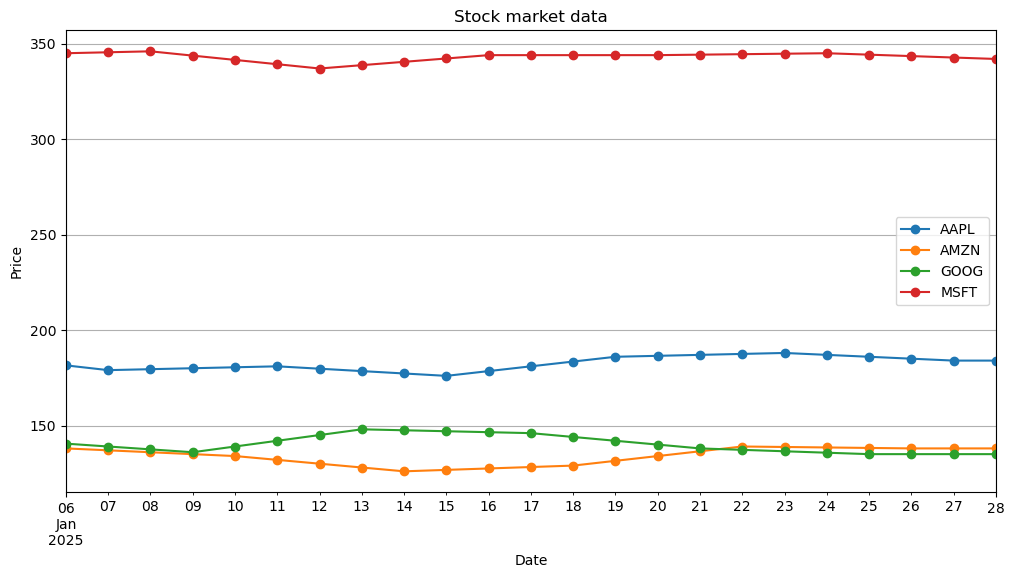

In [94]:
cleaned_converted_pivoted_stock_df.plot(marker="o",linestyle="-",figsize=(12,6))
plt.title("Stock market data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

### 4. Education (Student Scores)

#### Generate student's marks data 

In [95]:
def generate_students_marks_data(students : List[str]=None, subjects:List[str]=None, num_rows:int=None) -> List[Dict[str,Any]]:
    # Raise TypeError if the agrs are not of correct datatype
    if not isinstance(students,list):
        raise TypeError("students must be of type List")
    if not isinstance(subjects,list):
        raise TypeError("subjects must be of type list")
    if not isinstance(num_rows,int):
        raise TypeError("num_rows must be of type int")

    # Raise ValueError if the any of the args are None
    if not students:
        raise ValueError("students is required!")
    if not subjects:
        raise ValueError("subjects is required!")
    if not num_rows:
        raise ValueError("num_rows is required!")

    data = []
    for _ in range(num_rows):
        student = random.choice(students)
        subject = random.choice(subjects)
        score = random.randint(50, 100)  # score range between 50–100
        data.append({"student": student, "subject": subject, "score": score})
    
    return data

In [96]:
# initialize data
students = ["Alice", "Bob", "Charlie", "David", "Eva", "Frank", "Grace", "Hannah"]
subjects = ["Math", "Science", "English", "History", "Art", "Physics"]
num_rows = 30

# create dataFrame
students_df = pd.DataFrame(generate_students_marks_data(students,subjects,num_rows))
students_df

,student,subject,score
0,David,Science,91
1,Grace,History,93
2,Hannah,Art,74
3,Charlie,Physics,73
4,Frank,Science,95
5,Charlie,Math,70
6,Eva,English,76
7,Alice,English,56
8,Grace,Physics,55
9,Frank,Art,68


#### Let's use groupby method here to analyze this data

**Average score per student:** 

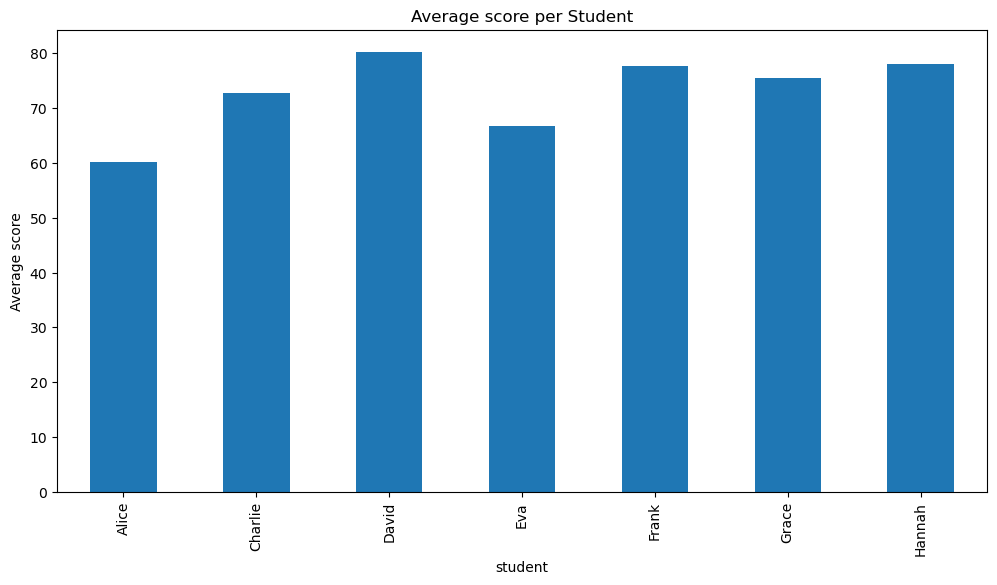

In [97]:
# group the data based on student name
groupby_student_df = students_df.groupby("student")

# select the score column and calculate mean
groupby_student_df["score"].mean().plot(kind="bar",figsize=(12,6))
plt.title("Average score per Student")
plt.ylabel("Average score")
plt.show()

#### Conclusion:
- Gives us the student's average score

**Average score per subject:**

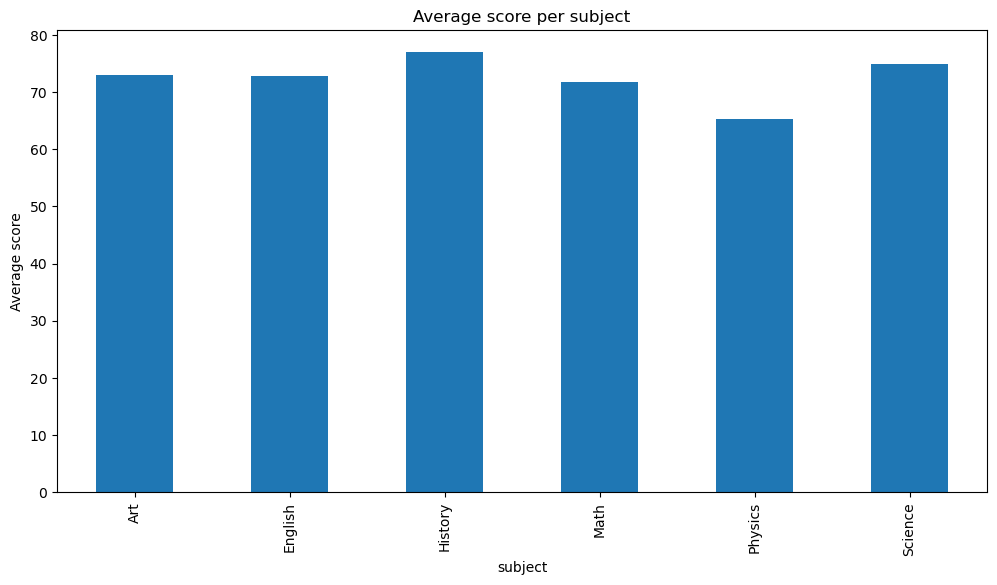

In [98]:
# group the data based on subject name
groupby_subject_df = students_df.groupby("subject")

# select the score column and calculate mean
groupby_subject_df["score"].mean().plot(kind="bar", figsize=(12,6))
plt.title("Average score per subject")
plt.ylabel("Average score")
plt.show()

#### Conclusion:
- This gives us subject's average performance

**Student performance across subjects (line plot)**

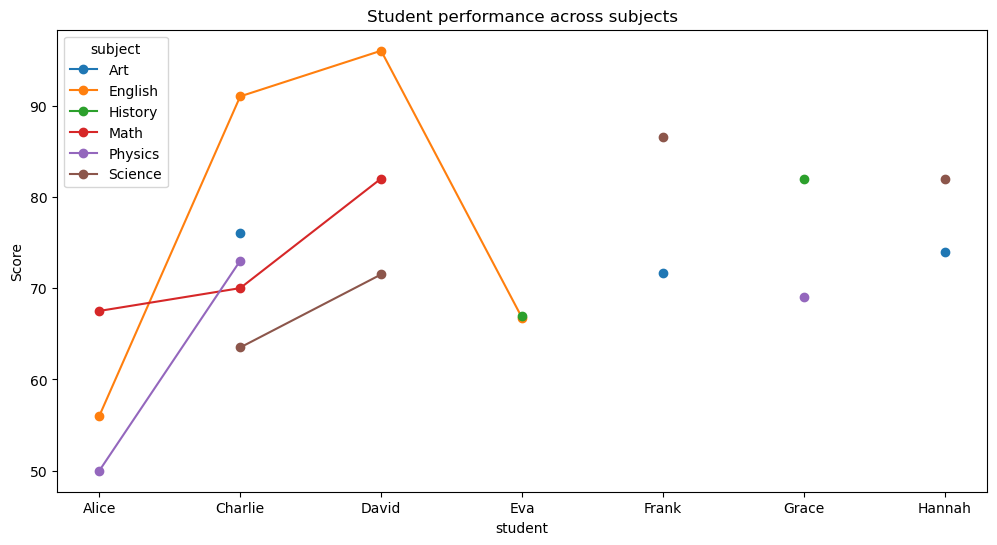

In [99]:
# group the data based on student, subject
groupedby_student_subject_df = students_df.groupby(["student","subject"])

# select the score column and calculate mean
group_unstacked = groupedby_student_subject_df["score"].mean().unstack()
group_unstacked.plot(kind="line",marker="o",figsize=(12,6))
plt.title("Student performance across subjects")
plt.ylabel("Score")
plt.show()

#### Conclusion:
- Each student have a line showing their scortes in different subjects
- Not very useful I just plotted it for fun.

**Subject-wise distribution of scores (boxplot)**

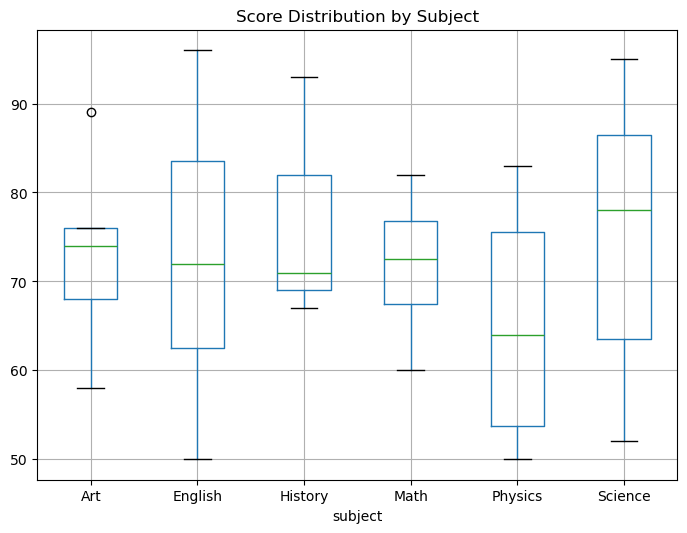

In [100]:
students_df.boxplot(column="score", by="subject", figsize=(8,6))
plt.title("Score Distribution by Subject")
plt.suptitle("")  # remove extra title
plt.show()

#### Conclusion:
- Helps analyze score spread per subject

#### Let's use pivot method here to analyze this data

In [101]:
# initialize data
students = ["Alice", "Bob", "Charlie", "David", "Eva", "Frank", "Grace", "Hannah"]
subjects = ["Math", "Science", "English", "History", "Art", "Physics"]
num_rows = 30

# create dataFrame
students_df2 = pd.DataFrame(generate_students_marks_data(students,subjects,num_rows))
students_df2

,student,subject,score
0,Frank,Art,63
1,Alice,Math,61
2,Frank,Physics,63
3,Alice,English,83
4,Frank,English,72
5,Hannah,Art,96
6,Hannah,Science,97
7,Hannah,Math,55
8,Bob,Physics,52
9,Hannah,History,83


In [102]:
pivoted_students_df2 = students_df2.pivot(index="student",columns="subject",values="score")
pivoted_students_df2

ValueError: Index contains duplicate entries, cannot reshape

#### Error analysis:
Notice the data in this dataFrame ```pivoted_students_df2``` here you can see that some students have multiple scores for the same subject (duplicates in ```student``` + ```subject``` combination).
```.pivot()``` only works if the index-column pairs are unique or else it throws a ValueError.

#### Solution : 
The solution is to use ```pivot_table``` instead of ```pivot```. All I have to do is tell pandas to aggregate duplicate values (example: mean,max,min,sum ... etc.)

In [103]:
pivoted_students_df2 = students_df2.pivot_table(index="student", columns="subject", values="score", aggfunc="mean")
pivoted_students_df2

subject,Art,English,History,Math,Physics,Science
student,,,,,,
Alice,NaN,85.0,NaN,61.0,NaN,NaN
Bob,76.0,NaN,66.0,NaN,52.0,60.0
Charlie,NaN,NaN,83.5,NaN,NaN,NaN
David,94.0,67.0,65.0,54.0,76.0,56.0
Eva,NaN,81.0,80.0,86.0,NaN,NaN
Frank,63.0,72.0,NaN,NaN,60.0,NaN
Grace,NaN,NaN,66.0,80.0,NaN,NaN
Hannah,96.0,NaN,70.5,55.0,NaN,97.0


#### Let's plot the data in the graph

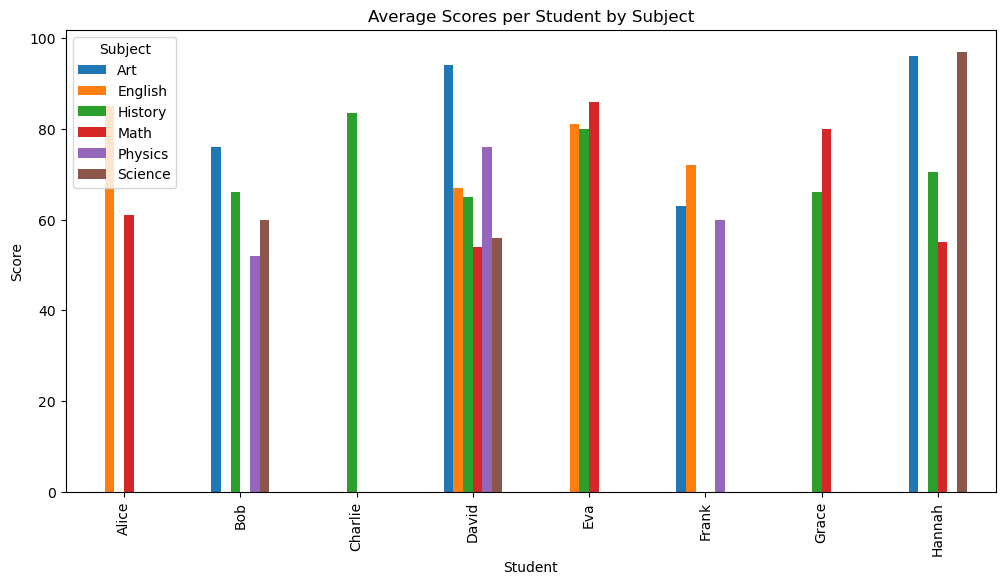

In [104]:
pivoted_students_df2.plot(kind="bar", figsize=(12,6))
plt.title("Average Scores per Student by Subject")
plt.ylabel("Score")
plt.xlabel("Student")
plt.legend(title="Subject")
plt.show()

## So what is ```.pivot_table()```?
In Pandas ```.pivot_table()``` is like ```.pivot()``` but more powerful and flexible.
### Difference between ```.pivot()``` and ```.pivot_table()```
- ```.pivot()```: **reshapes data**, but fails if there are duplicates for the same ```index/column``` pair.
- ```.pivot()```: **reshapes data + allows aggregation** when duplicates exists it performs SQL like ```GROUPBY``` operation.

### What does this line mean? -> (```.pivot()```: **reshapes data + allows aggregation** when duplicates exists it performs SQL like ```GROUPBY``` operation.)
#### 1. Reshaping (like ```.pivot()```):
It changes your DataFrame layout from long format -> wide format.
- ```index``` -> rows
- ```columns``` -> new columns
- ```values``` -> data to fill in the cells

<br>

This part is exactly what ```.pivot()``` does.

#### 2. Aggregation (like SQL ```GROUP BY```):
If you have **multiple rows with the same** ```index``` + ```column``` **pair**, ```.pivot()``` will throw an error.
```.pivot_table()``` instead aggregates those multiple values using a function like:
- ```mean``` (DEFAULT) behaviour
- ```sum```
- ```count```
- ```min```,```max```
- or even a dev defined custom function

<br>

That's why ```.pivot_table()``` is like **pivot + groupby aggregation in SQL** <br>
**NOTICE:** We have the ability to apply more than one aggregation function example: ```df.pivot_table(index="date", columns="city", values="temperature", aggfunc=["mean","max","min"])```

### Case 1: Sales Transactions (Pivot Fails, Pivot_table Works)

#### Generate data function:

In [130]:
from typing import List,Optional,Union,Optional
from datetime import datetime, date
# This function generates data for us to use in this example
# This dataFrame will generate unique date index if allow_duplicate ex:0.2 is set to True and dup_fraction is supplied
def generate_sales_data(start_date:Union[str, pd.Timestamp, datetime, date] = None,
                        periods:int=None,
                        products:List[str]=None,
                        allow_duplicates: Optional[bool] = False,
                        dup_fraction: Optional[float] = None)->pd.DataFrame:
    # check the type of each argument passed in this function
    if not isinstance(start_date, (str, pd.Timestamp, datetime, date)):
        raise TypeError("start_date must be of datetime type")
    if not isinstance(periods,int):
        raise TypeError("periods must of integer type")
    if not isinstance(products,list):
        raise TypeError("products must be of list type")
    if not isinstance(allow_duplicates,bool):
        raise TypeError("allow_duplicates must be of boolean type")

    # check if the argument has data in it
    if not start_date:
        raise ValueError("start_date required!")
    if not periods:
        raise ValueError("periods required!")
    if not products:
        raise ValueError("products required!")
    if allow_duplicates:
        if not isinstance(dup_fraction,float):
            raise TypeError("dup_fraction must be of float type")
        if not dup_fraction:
            raise ValueError("When allow_duplicate is set to True then dup_fraction is required!")

    # generate date range
    dates = pd.date_range(start=start_date,periods=periods,freq="D")

    # repeat products in the list for each date 
    date_col = np.repeat(dates,len(products))
    date
    product_col = products * len(dates)

    # Random sales values between 50 and 2000
    sales_col = np.random.randint(50,2000,size=len(date_col))

    # Build DataFrame
    df=pd.DataFrame(
        {
            "date":date_col,
            "product":product_col,
            "sales":sales_col
        }
    )
    if allow_duplicates:
        dup_count = max(1, int(len(df) * dup_fraction))  # how many rows to duplicate
        dup_rows = df.sample(dup_count, replace=True)
        df = pd.concat([df, dup_rows]).sample(frac=1).reset_index(drop=True)
    return df

### Explaination:
1. ```pd.date_range(start=start_date,periods=periods,freq="D")```
   - ```pd.date_range()```: generates a sequence of dates.
   - ```start=start_date```: the fist date of the sequence (example: ```"2025-01-01"```).
   - ```periods=periods```: how many dates to generate. If ```periods=5```, and ```start="2025-01-01"```, you'll get:
     - ```2025-01-01, 2025-01-02, 2025-01-03, 2025-01-04, 2025-01-05```
   - ```freq="D"``` : frequency of the dates. ```"D"``` means daily. Other example:
     - ```"M"```:month end
     - ```"W"```:weekly
     - ```"H"```:hourly
   - So periods = number of time steps, and freq = the spacing between them. 
2. ```date_col = np.repeat(dates, len(products))```
   - ```np.repeat(array, n)```: It repeats each element inside the array n times in a row.
     - ```python
            np.repeat([1,2,3], 2)
            # Output: [1,1,2,2,3,3]
       ```
     - In my code:
       - ```dates```=```[2025-01-01, 2025-01-02, ...]```
       - ```len(products)```=number of product types (say 6).
       - So if ```dates = [2025-01-01, 2025-01-02]``` and ```products = 6``` items, then:
         ```python
             date_col = [2025-01-01,2025-01-01,2025-01-01,2025-01-01,2025-01-01,2025-01-01,
            2025-01-02,2025-01-02,2025-01-02,2025-01-02,2025-01-02,2025-01-02]
         ```
3. ```product_col = products * len(dates)```
   - In Python, multiplying a list by an integer **repeats the list.**
     Example:
     ```python
        products = ["Laptop","Mouse"]
        products * 3
        # ['Laptop','Mouse','Laptop','Mouse','Laptop','Mouse']
     ```
   - ```len(dates)```=number of dates generate.
   - So if ```products=["Laptop","Mouse"]``` and ```len(dates)=2```, you get:
     ```python
        ['Laptop','Mouse','Laptop','Mouse']
     ```
     - This ensures that for every date, you have all products listed once.
4. Handling duplicates:
   - ```python
        if allow_duplicates:
            dup_count = max(1, int(len(df) * dup_fraction))  
            dup_rows = df.sample(dup_count, replace=True)
            df = pd.concat([df, dup_rows]).sample(frac=1).reset_index(drop=True)
     ```
     - ```dup_count = max(1, int(len(df) * dup_fraction))```
       - ```len(df)```=total number of rows in the dataFrame
       - ```dup_fraction```=fraction of rows you want to duplicate
       - ```len(df) * dup_fraction```=number of duplicate rows.
         - Example:if ```len(df)=100``` and ```dup_fraction=0.2``` -> 20 rows.
       - ```int(...)``` ensures that atleast one row gets duplicated otherwise it might round down to 0
       - ```max(1,...)``` ensures that at least 1 row is duplicated (otherwise it might round down to 0)
     - ```dup_rows = df.sample(dup_count, replace=True)```
        - ```df.sample(n)``` picks ```n``` random rows from a dataFrame.
        - ```replace=True```means the same row can be picked more than once.
        - So this will select dup_count rows to be duplicated.
     - ```df = pd.concat([df, dup_rows]).sample(frac=1).reset_index(drop=True)```
       - ```pd.concat([df, dup_rows])``` adds the duplicate rows back into the dataFrame.
       - ```.sample(frac=1)``` shuffles all rows.
         - ```fract=1``` means "take 100% of the rows but in random order".
       - ```.reset_index(drop=True)``` resets the row index back to ```0...N-1```.
         - ```drop=True``` means don't keep the old index as a column.
       - This makes the dataset look like it naturally has some reapeated dates/products, instead of all duplicates grouped at the buttom.

#### prepare argument data for the ```generate_sales_data()``` function

In [126]:
start_date="2025-01-01"
products=["Laptop","Keyboard","Mouse","Mouse Pad","Printer","Wireless Headphones"]
periods=30
products_df=generate_sales_data(start_date,periods,products)
products_df

,date,product,sales
0,2025-01-01,Laptop,716
1,2025-01-01,Keyboard,1861
2,2025-01-01,Mouse,1370
3,2025-01-01,Mouse Pad,1749
4,2025-01-01,Printer,1351
...,...,...,...
175,2025-01-30,Keyboard,301
176,2025-01-30,Mouse,1279
177,2025-01-30,Mouse Pad,1082
178,2025-01-30,Printer,1952


#### Let's try to reshape this dataFrame using ```.pivot()``` function

In [127]:
pivoted_product_df = products_df.pivot(index="date",columns="product",values="sales")
pivoted_product_df

product,Keyboard,Laptop,Mouse,Mouse Pad,Printer,Wireless Headphones
date,,,,,,
2025-01-01,1861,716,1370,1749,1351,1428
2025-01-02,114,1043,113,953,1989,936
2025-01-03,1644,55,1685,209,1257,1454
2025-01-04,1605,628,416,1797,1162,456
2025-01-05,1646,869,837,1187,1287,1094
2025-01-06,1774,1441,1002,1371,517,1490
2025-01-07,101,1749,1857,1448,458,790
2025-01-08,168,1543,225,1573,526,1720
2025-01-09,875,941,1525,1978,858,440


#### Analysis 
The reason why the ```.pivot()``` function worked properly is because the dates index is unique

#### What if the date index has duplicate dates in it?

In [128]:
start_date="2025-01-01"
products=["Laptop","Keyboard","Mouse","Mouse Pad","Printer","Wireless Headphones"]
periods=30
duplicate_date_index_df = generate_sales_data(start_date=start_date, periods=periods, products=products, allow_duplicates=True,dup_fraction=0.2)
duplicate_date_index_df

,date,product,sales
0,2025-01-12,Wireless Headphones,1605
1,2025-01-23,Mouse,1711
2,2025-01-30,Laptop,594
3,2025-01-26,Mouse Pad,1029
4,2025-01-05,Wireless Headphones,1113
...,...,...,...
211,2025-01-29,Laptop,1382
212,2025-01-23,Mouse Pad,1570
213,2025-01-15,Mouse,781
214,2025-01-06,Mouse Pad,1759


In [129]:
pivoted_dupkicate_date_index_df=duplicate_date_index_df.pivot(index="date",columns="product",values="sales")
pivoted_duplictae_date_index_df

ValueError: Index contains duplicate entries, cannot reshape

#### Analysis:
This is exactly where the ```.pivot()``` function will fail since the dataFrame has duplicate date entries set as index. <br>
So what's the solution ? : <br>
The solution is to use ```pivot_table()``` instead of ```pivot()```

### Let's try ```.pivot_table()``` function:

In [132]:
pivoted_table_df = duplicate_date_index_df.pivot_table(index="date",columns="product",values="sales",aggfunc="sum")
pivoted_table_df

product,Keyboard,Laptop,Mouse,Mouse Pad,Printer,Wireless Headphones
date,,,,,,
2025-01-01,1114,1130,782,1024,715,1786
2025-01-02,1918,1288,1068,1203,716,1954
2025-01-03,664,676,1625,1941,875,771
2025-01-04,1887,1913,1108,3572,4083,283
2025-01-05,630,1242,877,2104,1467,1113
2025-01-06,1888,1213,312,5277,1013,583
2025-01-07,650,3056,754,392,177,1711
2025-01-08,794,1029,1779,395,1009,828
2025-01-09,1194,510,146,1347,1954,1017


#### Analysis:
- The reason I used ```aggfunc="sum"``` because it makes most sense if you think in terms of **total sales aggregation** (sales additive in real-world senarios)
- If instead, I wanted to study the ```typical behavior of sales per product per day```, ```aggfunc="mean"``` would be appropriate.
#### Cho